In [1]:
from google.colab import drive
import gzip
import random
import networkx as nx
from collections import deque
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

drive.mount('/content/drive')

%cd /content/drive/MyDrive/Colab Notebooks/AM

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/AM


In [2]:
adj = {}

with gzip.open('web-Google.txt.gz', 'rt') as f:
  for line in f:
    if line.startswith('#'):
      continue
    u, v = map(int, line.split())
    adj.setdefault(u, []).append(v)
    adj.setdefault(v, []) # ensure node exists

start = random.choice(list(adj.keys()))
visited = set([start])
queue = deque([start])

while queue and len(visited) < 300:
  node = queue.popleft()
  for neighbor in adj.get(node, []):
    if neighbor not in visited:
      visited.add(neighbor)
      queue.append(neighbor)
    if len(visited) >= 300:
      break

# keep edges inside sampled nodes
sample_edges = [(u, v) for u in visited for v in adj.get(u, []) if v in visited]

In [3]:
G = nx.DiGraph()
G.add_nodes_from(visited)
G.add_edges_from(sample_edges)

print(f"Nodes: {nx.number_of_nodes(G)}, Vertices: {nx.number_of_edges(G)}")

Nodes: 300, Vertices: 1317


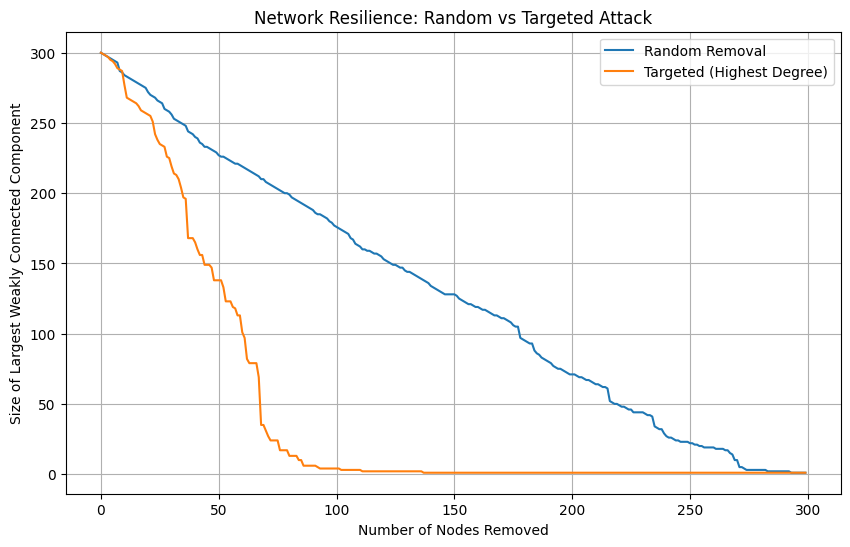

In [4]:
def get_lwcc_size(graph):
  if len(graph) == 0:
    return 0
  components = nx.weakly_connected_components(graph)
  return len(max(components, key=len))

def simulate_removal(graph, strategy='random'):
  temp_graph = graph.copy()
  initial_nodes = list(temp_graph.nodes())
  num_nodes = len(initial_nodes)

  resilience_curve = [get_lwcc_size(temp_graph)]

  # Remove nodes one by one
  for _ in range(num_nodes - 1):
    if strategy == 'random':
        node_to_remove = random.choice(list(temp_graph.nodes()))
    elif strategy == 'targeted':
      # Target node with highest degree
      degrees = dict(temp_graph.degree())
      node_to_remove = max(degrees, key=degrees.get)

    temp_graph.remove_node(node_to_remove)
    resilience_curve.append(get_lwcc_size(temp_graph))

  return resilience_curve

random_curve = simulate_removal(G, strategy='random')
targeted_curve = simulate_removal(G, strategy='targeted')

plt.figure(figsize=(10, 6))
plt.plot(range(len(random_curve)), random_curve, label='Random Removal')
plt.plot(range(len(targeted_curve)), targeted_curve, label='Targeted (Highest Degree)')
plt.title('Network Resilience: Random vs Targeted Attack')
plt.xlabel('Number of Nodes Removed')
plt.ylabel('Size of Largest Weakly Connected Component')
plt.legend()
plt.grid(True)
plt.show()

Web-like networks are typically robust against random failures because most nodes have low degrees; removing them doesn't significantly fragment the network.
They are highly fragile to targeted attacks. Because the connectivity relies on a few 'hubs', removing these hubs causes the network to collapse much faster than random removal.

**Proposed Policy/Design Change:**
To improve the resilience of this web infrastructure, one could implement **decentralization policies**. Instead of allowing a few domains to accumulate the vast majority of incoming links (the 'rich-get-richer' phenomenon), search engine algorithms or web standards could prioritize 'bridge' nodes that connect different communities. By increasing the density of connections between non-hub nodes (increasing the *redundancy* of paths), the network would remain functional even if major hubs are compromised.